### Utilizar y cargar las librerías necesarías para el EDA

In [42]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, '../src')
from extraccion import Extraccion

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


#### Iniciar la conexión a MongoDB

In [43]:
ext = Extraccion(uri='mongodb://localhost:27017', db_name='airbnb_argentina')
ext.conectar()
dfs = ext.extraer_todo()
ext.cerrar_conexion()

df_listings  = dfs['listings']
df_calendar  = dfs['calendar']
df_reviews   = dfs['reviews']

print(f'Listings:  {df_listings.shape[0]:,} filas × {df_listings.shape[1]} columnas')
print(f'Calendar:  {df_calendar.shape[0]:,} filas × {df_calendar.shape[1]} columnas')
print(f'Reviews:   {df_reviews.shape[0]:,} filas × {df_reviews.shape[1]} columnas')

2026-04-11 19:54:28 | INFO     | extraccion | Extraccion inicializada — URI: mongodb://localhost:27017 | DB: airbnb_argentina
2026-04-11 19:54:28 | INFO     | extraccion | Intentando conectar a MongoDB...
2026-04-11 19:54:28 | INFO     | extraccion | Conexión exitosa a MongoDB — Base de datos: 'airbnb_argentina'
2026-04-11 19:54:28 | INFO     | extraccion | Colecciones disponibles: ['calendar', 'reviews', 'listings']
2026-04-11 19:54:28 | INFO     | extraccion | === Iniciando extracción completa de colecciones ===
2026-04-11 19:54:28 | INFO     | extraccion | Extrayendo colección: 'listings'...
2026-04-11 19:54:34 | INFO     | extraccion |   ✓ 'listings': 27,348 registros | 71 columnas
2026-04-11 19:54:34 | INFO     | extraccion | Extrayendo colección: 'reviews'...
2026-04-11 19:54:51 | INFO     | extraccion |   ✓ 'reviews': 1,042,702 registros | 6 columnas
2026-04-11 19:54:51 | INFO     | extraccion | Extrayendo colección: 'calendar'...
2026-04-11 20:06:30 | INFO     | extraccion |   

Listings:  27,348 filas × 71 columnas
Calendar:  9,982,072 filas × 5 columnas
Reviews:   1,042,702 filas × 6 columnas


# Punto 2: Analisis exploratorio de datos (EDA)

## Item 2.1. Entendimiento general de los datos

### Para cada colección:

#### Mostrar las primeras filas

Para la colección de Listings

In [44]:
print('=== Primeras 5 filas de Listings ===')
df_listings.head(5)

=== Primeras 5 filas de Listings ===


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_picture_url,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_location,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,host_about,license
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,7,2,5,11,True,https://a0.muscache.com/im/pictures/user/ba7f6...,3,None,True,True,San Nicolas,-34.60,...,244,2026-01-25,0,0,0,220,0,0,2,2,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,11,0,3,7,False,https://a0.muscache.com/im/users/25649070/prof...,1,None,True,True,San Nicolas,-34.60,...,307,2026-01-25,1,0,0,283,1,0,1,1,0,0,"Autonomous City of Buenos Aires, Argentina",2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0.08,NaN,NaN
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,8,3,7,10,False,https://a0.muscache.com/im/pictures/user/4e988...,1,None,True,True,Balvanera,-34.60,...,326,2026-01-25,0,0,0,302,0,0,1,1,0,0,"Olivos, Argentina",NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Responsable amable atento y amigable,NaN
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,1462517876404348407,https://www.airbnb.com/users/profile/146251787...,Marian,14,2,14,1,False,https://a0.muscache.com/im/pictures/user/User-...,48,None,True,True,Balvanera,-34.60,...,365,2026-01-25,22,3,0,341,3,18,39,34,4,0,"Buenos Aires, Argentina",2023-10-29,2025-12-07,4.73,4.64,4.64,4.82,4.73,4.59,4.45,0.80,I'm a young entrepreneur who enjoys the pleasu...,NaN
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,https://www.airbnb.com/users/show/467965425,1470109782901816721,https://www.airbnb.com/users/profile/147010978...,Maria Del Carmen,3,6,2,8,False,https://a0.muscache.com/im/pictures/user/dbfd3...,2,None,True,True,Almagro,-34.60,...,365,2026-01-25,0,0,0,341,0,0,2,2,0,0,"Buenos Aires, Argentina",NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,N

In [45]:
print(f'Shape: {df_listings.shape}')
df_listings.info()

Shape: (27348, 71)
<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 71 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27348 non-null  int64         
 1   listing_url                                   27348 non-null  str           
 2   scrape_id                                     27348 non-null  int64         
 3   last_scraped                                  27348 non-null  datetime64[us]
 4   source                                        27348 non-null  str           
 5   name                                          27348 non-null  str           
 6   description                                   26752 non-null  str           
 7   picture_url                                   27347 non-null  str           
 8   host_id                                       27348 non-nu

In [46]:
# Descripción estadística de variables numéricas relevantes
cols_num = ['price', 'minimum_nights', 'maximum_nights', 'availability_365',
            'number_of_reviews', 'review_scores_rating', 'reviews_per_month']
cols_existentes = [c for c in cols_num if c in df_listings.columns]
df_listings[cols_existentes].describe().round(2)

,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month
count,27242.00,27242.00,27348.00,27348.00,24045.00,24045.00
mean,4.75,586.12,240.00,38.13,4.78,1.46
std,16.43,434.07,113.61,56.08,0.36,1.56
min,1.00,1.00,0.00,0.00,1.00,0.01
25%,1.00,365.00,151.00,4.00,4.73,0.39
50%,2.00,365.00,269.00,17.00,4.87,1.00
75%,3.00,1125.00,344.00,51.00,4.98,2.03
max,730.00,1825.00,365.00,1044.00,5.00,28.69


Para la colección de Calendar

In [47]:
df_calendar.head(5)

,listing_id,date,available,minimum_nights,maximum_nights
0,11508,2026-01-26,False,3,1125
1,11508,2026-01-27,False,3,1125
2,11508,2026-01-28,False,3,1125
3,11508,2026-01-29,False,3,1125
4,11508,2026-01-30,False,3,1125


In [48]:
print(f'Shape: {df_calendar.shape}')
df_calendar.info()

Shape: (9982072, 5)
<class 'pandas.DataFrame'>
RangeIndex: 9982072 entries, 0 to 9982071
Data columns (total 5 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   available       bool          
 3   minimum_nights  int64         
 4   maximum_nights  int64         
dtypes: bool(1), datetime64[us](1), int64(3)
memory usage: 314.1 MB


Para la colección de Reviews

In [49]:
df_reviews.head(5)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,11508,1615861,2012-07-02,877808,Charlie,Amazing place!\r<br/>\r<br/>Location: short wa...
1,11508,3157005,2012-12-26,656077,Shaily,Really enjoyed Candela's recommendations and q...
2,11508,3281011,2013-01-05,2835998,Michiel,Candela and her colleague were very attentive ...
3,11508,6050019,2013-07-28,4600436,Tara,"The apartment was in a beautiful, modern build..."
4,11508,9328455,2013-12-22,3130017,Simon,My stay at Candela's apartment was very enjoya...


In [50]:
print(f'Shape: {df_reviews.shape}')
df_reviews.info()

Shape: (1042702, 6)
<class 'pandas.DataFrame'>
RangeIndex: 1042702 entries, 0 to 1042701
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   listing_id     1042702 non-null  int64         
 1   id             1042702 non-null  int64         
 2   date           1042702 non-null  datetime64[us]
 3   reviewer_id    1042702 non-null  int64         
 4   reviewer_name  1042701 non-null  object        
 5   comments       1042702 non-null  object        
dtypes: datetime64[us](1), int64(3), object(2)
memory usage: 47.7+ MB


## 2.2. Calidad de los datos

#### Identificación de valores nulos

In [51]:
def resumen_nulos(df, nombre):
    """Genera un resumen de nulos ordenado por porcentaje."""
    nulos = df.isnull().sum()
    porcentaje = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({'nulos': nulos, 'porcentaje': porcentaje})
    resumen = resumen[resumen['nulos'] > 0].sort_values('porcentaje', ascending=False)
    print(f'\n=== Nulos en {nombre} ({len(resumen)} columnas con nulos) ===')
    display(resumen.head(20))
    return resumen

nulos_listings = resumen_nulos(df_listings, 'Listings')
nulos_calendar = resumen_nulos(df_calendar, 'Calendar')
nulos_reviews  = resumen_nulos(df_reviews, 'Reviews')


=== Nulos en Listings (26 columnas con nulos) ===


,nulos,porcentaje
license,26886,98.31
host_about,11783,43.09
host_location,5783,21.15
first_review,3303,12.08
review_scores_cleanliness,3303,12.08
review_scores_accuracy,3304,12.08
review_scores_rating,3303,12.08
last_review,3303,12.08
review_scores_communication,3303,12.08
review_scores_location,3303,12.08



=== Nulos en Calendar (0 columnas con nulos) ===


,nulos,porcentaje



=== Nulos en Reviews (1 columnas con nulos) ===


,nulos,porcentaje
reviewer_name,1,0.00


In [52]:
print('=== Filas con null ===')
df_listings[df_listings['has_availability'].isnull()].head(13)

=== Filas con null ===


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_picture_url,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_location,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,host_about,license
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,https://www.airbnb.com/users/show/467965425,1470109782901816721,https://www.airbnb.com/users/profile/147010978...,Maria Del Carmen,3,6,2,8,False,https://a0.muscache.com/im/pictures/user/dbfd3...,2,None,True,True,Almagro,-34.60,...,365,2026-01-25,0,0,0,341,0,0,2,2,0,0,"Buenos Aires, Argentina",NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"amante de la naturaleza, aire libre y aliment...",NaN
5,1587097677906378212,https://www.airbnb.com/rooms/1587097677906378212,20260125052844,2026-01-25,city scrape,Monoambiente moderno | Excelente ubicación,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,131466073,https://www.airbnb.com/users/show/131466073,1587097678664571673,https://www.airbnb.com/users/profile/158709767...,Federico,8,8,0,0,False,https://a0.muscache.com/im/Portrait/Avatars/me...,1,None,False,True,Almagro,-34.60,...,365,2026-01-25,0,0,0,341,0,0,1,1,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,1564746425329381889,https://www.airbnb.com/rooms/1564746425329381889,20260125052844,2026-01-25,city scrape,Fantástico departamento en Retiro,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,22931797,https://www.airbnb.com/users/show/22931797,1564746425906699520,https://www.airbnb.com/users/profile/156474642...,Mercedes,11,3,0,1,False,https://a0.muscache.com/im/pictures/user/7857b...,1,None,True,True,Retiro,-34.59,...,364,2026-01-25,0,0,0,340,0,0,1,1,0,0,"Victoria, Argentina",NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,848519105955089965,https://www.airbnb.com/rooms/848519105955089965,20260125052844,2026-01-25,city scrape,Appartement Recoleta,I am renting a room in my apartment (from June...,https://a0.muscache.com/pictures/miso/Hosting-...,505687012,https://www.airbnb.com/users/show/505687012,1463855884073592351,https://www.airbnb.com/users/profile/146385588...,Bérénice,2,10,2,10,False,https://a0.muscache.com/im/pictures/user/3237e...,1,None,True,True,Recoleta,-34.60,...,364,2026-01-25,0,0,0,340,0,0,1,0,1,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,1570224783992869584,https://www.airbnb.com/rooms/1570224783992869584,20260125052844,2026-01-25,city scrape,"Localização, luminoso, espaçoso e silencioso",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,710357220,https://www.airbnb.com/users/show/710357220,1570224784613209686,https://www.airbnb.com/users/profile/157022478...,Luis,0,5,0,1,False,https://a0.muscache.com/im/pictures/user/User/...,1,None,True,True,San Nicolas,-34.61,...,89,2026-01-25,0,0,0,89,0,0,1,1,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,664455861777839916,https://www.airbnb.com/rooms/664455861777839916,20260125052844,2026-01-26,city scrape,Individual Room in Palermo House -Piano - Patio,Small single room in a very nice PH type house...,https://a0.muscache.com/pictures/hosting/Hosti...,229

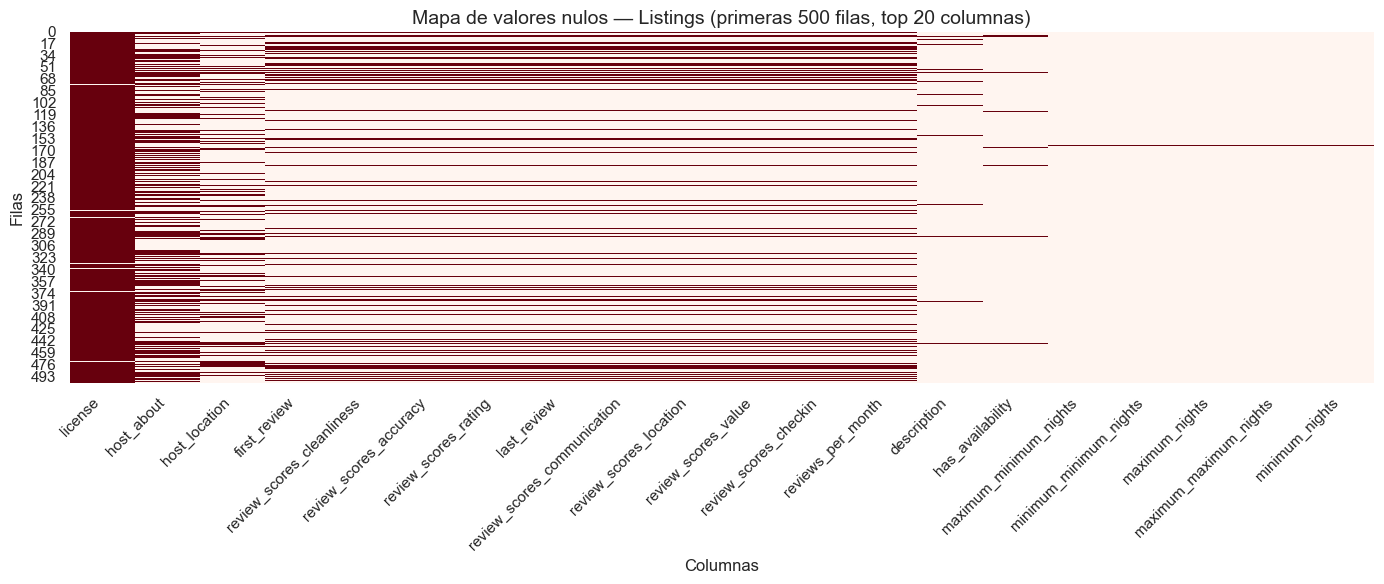

Gráfica guardada.


In [53]:
# Mapa de calor de nulos — Listings (top 20 columnas con más nulos)
top_nulos = nulos_listings.head(20).index.tolist()
if top_nulos:
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        df_listings[top_nulos].isnull().astype(int).head(500),
        cmap='Reds', cbar=False, ax=ax
    )
    ax.set_title('Mapa de valores nulos — Listings (primeras 500 filas, top 20 columnas)')
    ax.set_xlabel('Columnas')
    ax.set_ylabel('Filas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../data/grafica_nulos_listings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada.')

#### Registros duplicados

In [54]:
def df_hashable(df):
    """Convierte columnas con listas u objetos no hasheables a string para poder comparar duplicados."""
    df_temp = df.copy()
    for col in df_temp.columns:
        if df_temp[col].dtype == object:
            df_temp[col] = df_temp[col].apply(
                lambda x: str(x) if isinstance(x, (list, dict)) else x
            )
    return df_temp

for nombre, df in [('Listings', df_listings), ('Calendar', df_calendar), ('Reviews', df_reviews)]:
    df_safe = df_hashable(df)
    
    dup_total = df_safe.duplicated().sum()
    
    col_id = 'id' if 'id' in df_safe.columns else None
    if col_id:
        dup_id = df_safe[col_id].astype(str).duplicated().sum()
    else:
        dup_id = 'N/A'
    
    print(f'{nombre}: {dup_total} duplicados totales | {dup_id} duplicados por ID')

Listings: 0 duplicados totales | 0 duplicados por ID
Calendar: 0 duplicados totales | N/A duplicados por ID
Reviews: 0 duplicados totales | 0 duplicados por ID


#### Valores atípicos detectados

In [55]:
# Normalizar precio para análisis (eliminar $ y comas)
if 'price' in df_listings.columns:
    precio_num = (
        df_listings['price']
        .astype(str)
        .str.replace(r'[\$,\s]', '', regex=True)
        .replace('nan', None)
    )
    precio_num = pd.to_numeric(precio_num, errors='coerce')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Histograma precio
    precio_filtrado = precio_num[precio_num < precio_num.quantile(0.95)]
    axes[0].hist(precio_filtrado.dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title('Distribución de Precio (sin top 5%)')
    axes[0].set_xlabel('Precio')
    axes[0].set_ylabel('Frecuencia')

    # Boxplot precio
    axes[1].boxplot(precio_num.dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[1].set_title('Boxplot de Precio')
    axes[1].set_ylabel('Precio')

    # Boxplot minimum_nights
    if 'minimum_nights' in df_listings.columns:
        mn = pd.to_numeric(df_listings['minimum_nights'], errors='coerce')
        mn_filtrado = mn[mn < mn.quantile(0.99)]
        axes[2].boxplot(mn_filtrado.dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightgreen'))
        axes[2].set_title('Boxplot de Minimum Nights')
        axes[2].set_ylabel('Noches mínimas')

    plt.suptitle('Outliers en variables numéricas clave', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig('../data/grafica_outliers.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Estadísticas de outliers
    Q1, Q3 = precio_num.quantile(0.25), precio_num.quantile(0.75)
    IQR = Q3 - Q1
    outliers = precio_num[(precio_num < Q1 - 1.5*IQR) | (precio_num > Q3 + 1.5*IQR)]
    print(f'\nOutliers en precio (método IQR): {len(outliers):,} registros ({len(outliers)/len(precio_num)*100:.1f}%)')
    print(f'Precio mediano: ${precio_num.median():.2f}')
    print(f'Precio máximo: ${precio_num.max():.2f}')

### Distribución de variables categóricas

#### Tipo de habitación

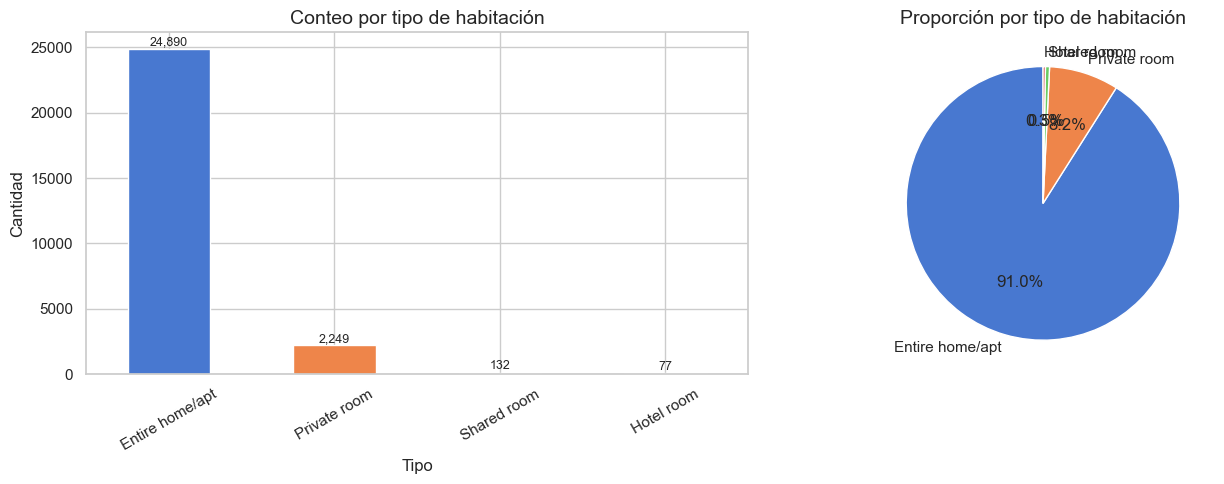

room_type
Entire home/apt    24890
Private room        2249
Shared room          132
Hotel room            77


In [56]:
import os
os.makedirs('../data', exist_ok=True)
if 'room_type' in df_listings.columns:
    conteo = df_listings['room_type'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Barras
    conteo.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'), edgecolor='white')
    axes[0].set_title('Conteo por tipo de habitación')
    axes[0].set_xlabel('Tipo')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=30)
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
    
    # Torta
    axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
                colors=sns.color_palette('muted'), startangle=90)
    axes[1].set_title('Proporción por tipo de habitación')
    
    plt.tight_layout()
    plt.savefig('../data/grafica_room_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(conteo.to_string())

#### Ver los datos con mas listings

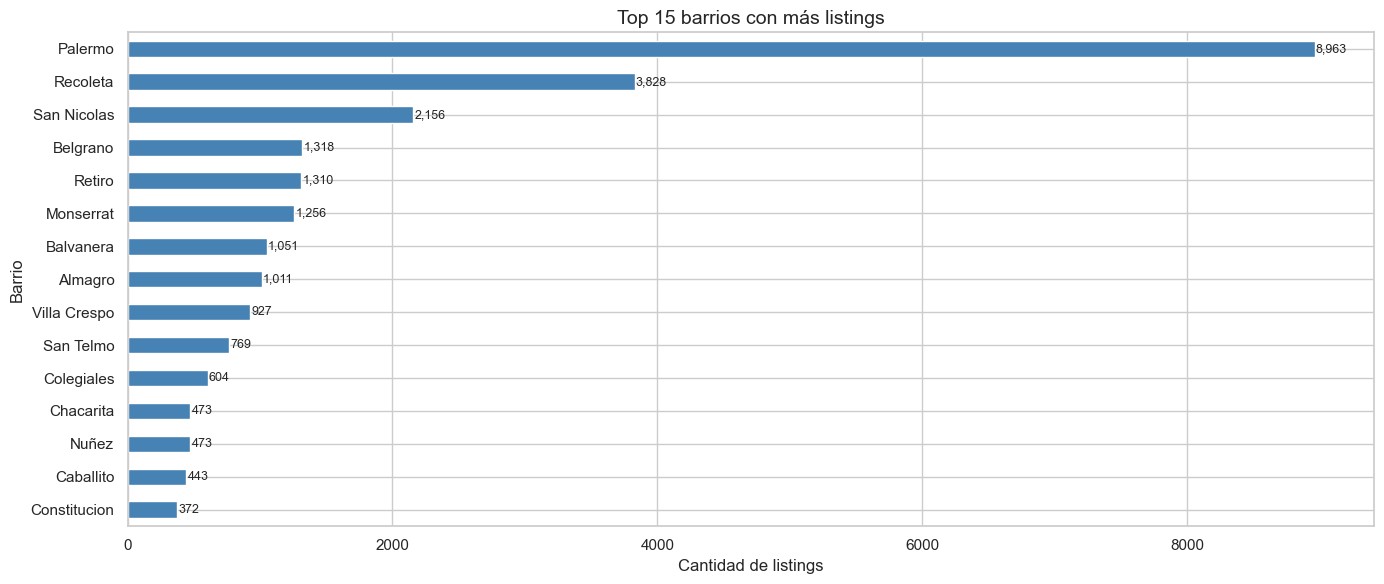

In [57]:
col_barrio = next((c for c in ['neighbourhood_cleansed', 'neighbourhood', 'neighborhood']
                   if c in df_listings.columns), None)

if col_barrio:
    top_barrios = df_listings[col_barrio].value_counts().head(15)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    top_barrios.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 15 barrios con más listings')
    ax.set_xlabel('Cantidad de listings')
    ax.set_ylabel('Barrio')
    for i, v in enumerate(top_barrios.sort_values()):
        ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../data/grafica_barrios.png', dpi=150, bbox_inches='tight')
    plt.show()

#### Disponibilidad promedio - Noches minimas y maximas - Ocupacion estimada

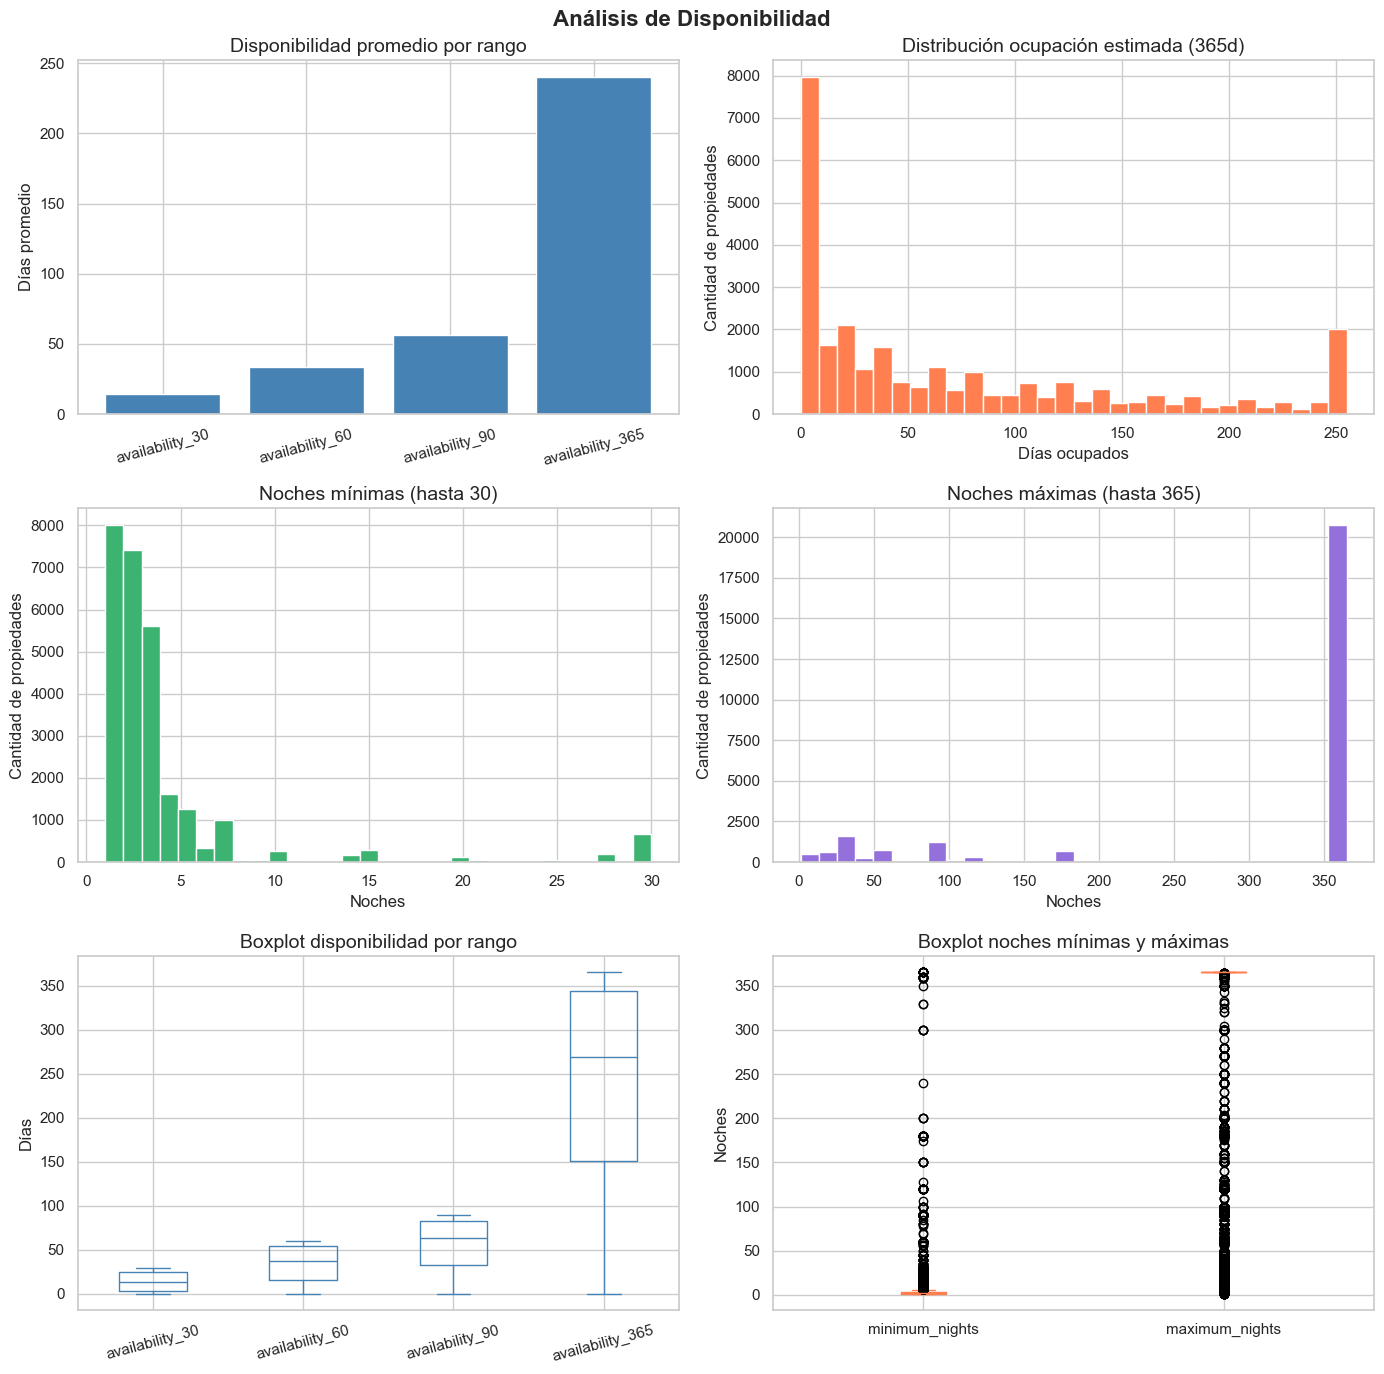

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Análisis de Disponibilidad', fontsize=16, fontweight='bold')

# 1. Disponibilidad promedio por rango
disponibilidad_media = df_listings[['availability_30', 'availability_60', 'availability_90', 'availability_365']].mean().round(2)
axes[0, 0].bar(disponibilidad_media.index, disponibilidad_media.values, color='steelblue')
axes[0, 0].set_title('Disponibilidad promedio por rango')
axes[0, 0].set_ylabel('Días promedio')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Distribución ocupación estimada
axes[0, 1].hist(df_listings['estimated_occupancy_l365d'].dropna(), bins=30, color='coral', edgecolor='white')
axes[0, 1].set_title('Distribución ocupación estimada (365d)')
axes[0, 1].set_xlabel('Días ocupados')
axes[0, 1].set_ylabel('Cantidad de propiedades')

# 3. Distribución noches mínimas (sin outliers)
min_nights = df_listings['minimum_nights'].clip(upper=30)
axes[1, 0].hist(min_nights, bins=30, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Noches mínimas (hasta 30)')
axes[1, 0].set_xlabel('Noches')
axes[1, 0].set_ylabel('Cantidad de propiedades')

# 4. Distribución noches máximas (sin outliers)
max_nights = df_listings['maximum_nights'].clip(upper=365)
axes[1, 1].hist(max_nights, bins=30, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Noches máximas (hasta 365)')
axes[1, 1].set_xlabel('Noches')
axes[1, 1].set_ylabel('Cantidad de propiedades')

# 5. Boxplot disponibilidad
df_listings[['availability_30', 'availability_60', 'availability_90', 'availability_365']].plot(
    kind='box', ax=axes[2, 0], color='steelblue'
)
axes[2, 0].set_title('Boxplot disponibilidad por rango')
axes[2, 0].set_ylabel('Días')
axes[2, 0].tick_params(axis='x', rotation=15)

# 6. Boxplot noches mínimas y máximas (sin outliers)
df_listings[['minimum_nights', 'maximum_nights']].clip(upper=365).plot(
    kind='box', ax=axes[2, 1], color='coral'
)
axes[2, 1].set_title('Boxplot noches mínimas y máximas')
axes[2, 1].set_ylabel('Noches')

plt.tight_layout()
plt.savefig('../data/Disponibilidad promedio.png', dpi=150, bbox_inches='tight')
plt.show()

#### Precio mediano por tipo de habitación

In [59]:
"""if 'room_type' in df_listings.columns and 'price' in df_listings.columns:
    df_temp = df_listings.copy()
    df_temp['price_num'] = pd.to_numeric(
        df_temp['price'].astype(str).str.replace(r'[\$,\s]', '', regex=True),
        errors='coerce'
    )
    precio_por_tipo = df_temp.groupby('room_type')['price_num'].median().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    precio_por_tipo.plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
    ax.set_title('Precio mediano por tipo de habitación')
    ax.set_xlabel('Tipo de habitación')
    ax.set_ylabel('Precio mediano')
    ax.tick_params(axis='x', rotation=30)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('../data/grafica_precio_room_type.png', dpi=150, bbox_inches='tight')
    plt.show()"""

"if 'room_type' in df_listings.columns and 'price' in df_listings.columns:\n    df_temp = df_listings.copy()\n    df_temp['price_num'] = pd.to_numeric(\n        df_temp['price'].astype(str).str.replace(r'[\\$,\\s]', '', regex=True),\n        errors='coerce'\n    )\n    precio_por_tipo = df_temp.groupby('room_type')['price_num'].median().sort_values(ascending=False)\n\n    fig, ax = plt.subplots(figsize=(10, 5))\n    precio_por_tipo.plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))\n    ax.set_title('Precio mediano por tipo de habitación')\n    ax.set_xlabel('Tipo de habitación')\n    ax.set_ylabel('Precio mediano')\n    ax.tick_params(axis='x', rotation=30)\n    for bar in ax.patches:\n        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,\n                f'${bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)\n    plt.tight_layout()\n    plt.savefig('../data/grafica_precio_room_type.png', dpi=150, bbox_inches='tight')\n    plt.show()"

#### Disponibilidad a lo largo del año 

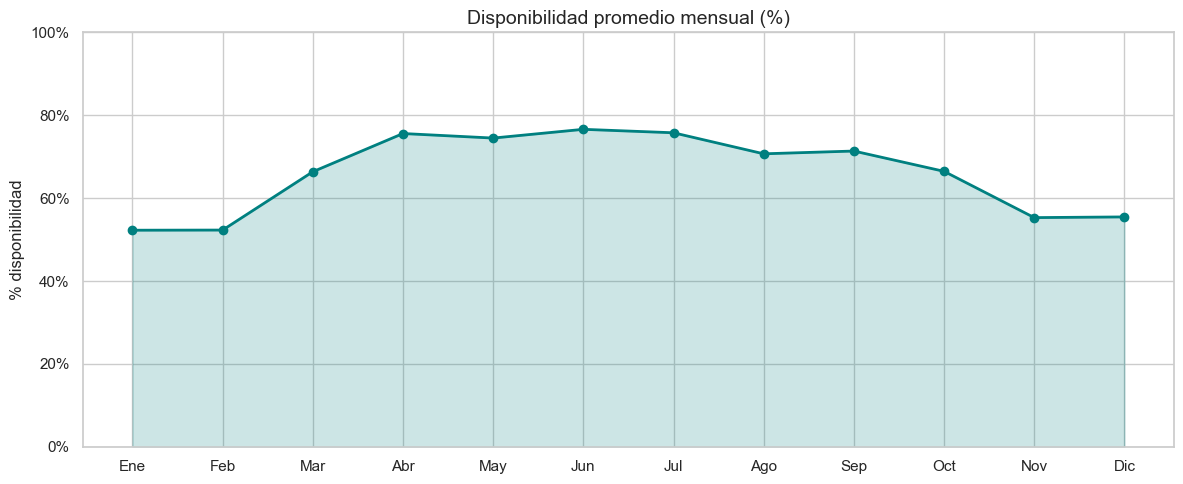

In [60]:
if 'available' in df_calendar.columns and 'date' in df_calendar.columns:
    df_cal = df_calendar.copy()
    df_cal['date'] = pd.to_datetime(df_cal['date'], errors='coerce')
    df_cal['mes'] = df_cal['date'].dt.month
    df_cal['disponible'] = df_cal['available'].map({'t': 1, 'f': 0, True: 1, False: 0})
    
    disponibilidad_mes = df_cal.groupby('mes')['disponible'].mean() * 100
    
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    disponibilidad_mes.index = [meses[i-1] for i in disponibilidad_mes.index]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    disponibilidad_mes.plot(kind='line', marker='o', ax=ax, color='teal', linewidth=2)
    ax.fill_between(range(len(disponibilidad_mes)), disponibilidad_mes.values, alpha=0.2, color='teal')
    ax.set_xticks(range(len(disponibilidad_mes)))
    ax.set_xticklabels(disponibilidad_mes.index)
    ax.set_title('Disponibilidad promedio mensual (%)')
    ax.set_ylabel('% disponibilidad')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig('../data/grafica_disponibilidad_mensual.png', dpi=150, bbox_inches='tight')
    plt.show()

#### Evolución de reviews por año

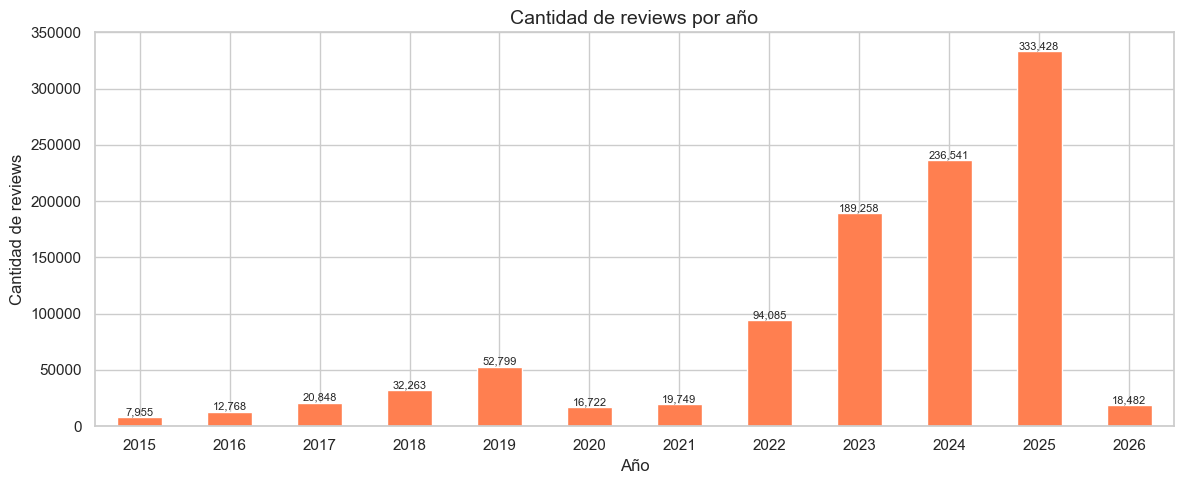

In [61]:
if 'date' in df_reviews.columns:
    df_rev = df_reviews.copy()
    df_rev['date'] = pd.to_datetime(df_rev['date'], errors='coerce')
    df_rev['anio'] = df_rev['date'].dt.year
    
    reviews_anio = df_rev['anio'].value_counts().sort_index()
    reviews_anio = reviews_anio[reviews_anio.index >= 2015]  # Filtrar años relevantes
    
    fig, ax = plt.subplots(figsize=(12, 5))
    reviews_anio.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title('Cantidad de reviews por año')
    ax.set_xlabel('Año')
    ax.set_ylabel('Cantidad de reviews')
    ax.tick_params(axis='x', rotation=0)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig('../data/grafica_reviews_anio.png', dpi=150, bbox_inches='tight')
    plt.show()

### Correlaciones entre variables numéricas

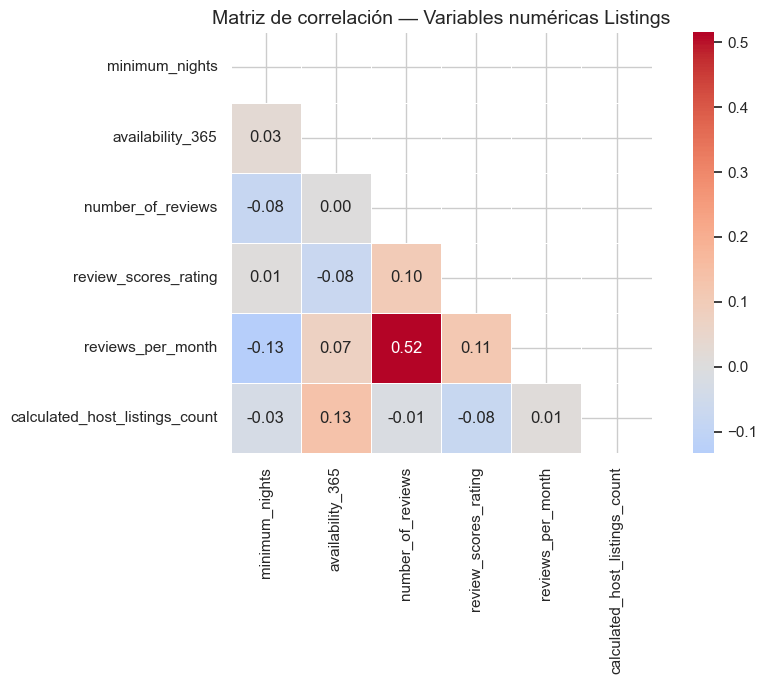

In [62]:
cols_correlacion = ['minimum_nights', 'availability_365', 'number_of_reviews',
                    'review_scores_rating', 'reviews_per_month', 'calculated_host_listings_count']
cols_existentes = [c for c in cols_correlacion if c in df_listings.columns]

if len(cols_existentes) >= 3:
    df_corr = df_listings[cols_existentes].apply(pd.to_numeric, errors='coerce')
    corr_matrix = df_corr.corr()
    
    fig, ax = plt.subplots(figsize=(10, 7))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, ax=ax,
        square=True, linewidths=0.5
    )
    ax.set_title('Matriz de correlación — Variables numéricas Listings')
    plt.tight_layout()
    plt.savefig('../data/grafica_correlacion.png', dpi=150, bbox_inches='tight')
    plt.show()

### Analisis de transformaciones necesarias 

Campo amenities de la colección listings

In [63]:
if 'amenities' in df_listings.columns:
    muestra = df_listings['amenities'].dropna().head(3)
    for i, val in enumerate(muestra):
        print(f'Registro {i+1}: {str(val)[:200]}')
    print('\n→ El campo amenities es una lista en formato string. Se debe parsear con ast.literal_eval.')

Registro 1: ['Kitchen', 'Air conditioning', 'Wifi', 'TV']
Registro 2: ['Paid parking on premises', 'Air conditioning', 'Wifi', 'Exterior security cameras on property']
Registro 3: ['Smoke alarm', 'Wifi', 'Kitchen', 'Fire extinguisher', 'Air conditioning', 'First aid kit', 'TV']

→ El campo amenities es una lista en formato string. Se debe parsear con ast.literal_eval.


Campo price en la colección listings

In [64]:
"""if 'price' in df_listings.columns:
    print('Tipo actual:', df_listings['price'].dtype)
    print('Ejemplos:', df_listings['price'].dropna().head(5).tolist())
    print('\n→ Requiere eliminar $, comas y convertir a float.')"""

"if 'price' in df_listings.columns:\n    print('Tipo actual:', df_listings['price'].dtype)\n    print('Ejemplos:', df_listings['price'].dropna().head(5).tolist())\n    print('\n→ Requiere eliminar $, comas y convertir a float.')"

Campo date en la coleccion calendar

In [65]:
if 'date' in df_calendar.columns:
    print('Tipo actual:', df_calendar['date'].dtype)
    print('Ejemplos:', df_calendar['date'].dropna().head(5).tolist())
    print('\n→ Se convertirá a datetime y se derivarán: año, mes, día, trimestre.')

Tipo actual: datetime64[us]
Ejemplos: [Timestamp('2026-01-26 00:00:00'), Timestamp('2026-01-27 00:00:00'), Timestamp('2026-01-28 00:00:00'), Timestamp('2026-01-29 00:00:00'), Timestamp('2026-01-30 00:00:00')]

→ Se convertirá a datetime y se derivarán: año, mes, día, trimestre.
